In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
calendar=pd.read_csv('calendar.csv')
sellPrices=pd.read_csv('sell_prices.csv')
sales_train_evaluation=pd.read_csv('sales_train_evaluation.csv')

In [3]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [4]:
sellPrices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [5]:
sales_train_evaluation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


I will take one store to reduse complexy it and do not have Erorr "Unable to allocate 5.73 GiB"


In [6]:
# 1. Reduce data first
sales_small = sales_train_evaluation[
    sales_train_evaluation['store_id'] == 'CA_1'
]

# 2. Melt
sales_long = sales_small.melt(
    id_vars=['id','item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)

# 3. Merge calendar
df = sales_long.merge(calendar, on='d', how='left')

# 4. Merge prices
df = df.merge(
    sellPrices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

In [7]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [8]:
df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price'],
      dtype='object')

In [9]:
df.isnull().sum()


id                    0
item_id               0
dept_id               0
cat_id                0
store_id              0
state_id              0
d                     0
sales                 0
date                  0
wm_yr_wk              0
weekday               0
wday                  0
month                 0
year                  0
event_name_1    5436367
event_type_1    5436367
event_name_2    5905913
event_type_2    5905913
snap_CA               0
snap_TX               0
snap_WI               0
sell_price      1129842
dtype: int64

event is normal to not have it but price not


sales is number of unit 


In [10]:
price_null=df[df['sell_price'].isnull()]
price_null=price_null[['sell_price','sales','cat_id','date']]
price_null

,sell_price,sales,cat_id,date
0,NaN,0,HOBBIES,2011-01-29
1,NaN,0,HOBBIES,2011-01-29
2,NaN,0,HOBBIES,2011-01-29
3,NaN,0,HOBBIES,2011-01-29
4,NaN,0,HOBBIES,2011-01-29
...,...,...,...,...
5600783,NaN,0,FOODS,2016-02-08
5603832,NaN,0,FOODS,2016-02-09
5606881,NaN,0,FOODS,2016-02-10
5609930,NaN,0,FOODS,2016-02-11


In [11]:
isNotNull=df[df['sell_price'].notnull()]
isNotNull=isNotNull[['sell_price','sales','cat_id','date']]
isNotNull

,sell_price,sales,cat_id,date
7,0.46,12,HOBBIES,2011-01-29
8,1.56,2,HOBBIES,2011-01-29
9,3.17,0,HOBBIES,2011-01-29
11,5.98,0,HOBBIES,2011-01-29
14,0.70,4,HOBBIES,2011-01-29
...,...,...,...,...
5918104,2.98,2,FOODS,2016-05-22
5918105,2.48,0,FOODS,2016-05-22
5918106,3.98,1,FOODS,2016-05-22
5918107,1.28,1,FOODS,2016-05-22


In [12]:
df['sell_price'] = df.groupby('item_id')['sell_price'].ffill().bfill()

In [13]:
df['sell_price'].isnull().sum()

np.int64(0)

In [14]:
df['revenue'] = df['sales'] * df['sell_price'] 

In [15]:
df['revenue']

0          0.00
1          0.00
2          0.00
3          0.00
4          0.00
           ... 
5918104    5.96
5918105    0.00
5918106    3.98
5918107    1.28
5918108    5.00
Name: revenue, Length: 5918109, dtype: float64

In [16]:
df[(df['revenue'] == 0) & (df['sell_price'] > 0)][['sales','sell_price','revenue','date']]

,sales,sell_price,revenue,date
0,0,0.46,0.0,2011-01-29
1,0,0.46,0.0,2011-01-29
2,0,0.46,0.0,2011-01-29
3,0,0.46,0.0,2011-01-29
4,0,0.46,0.0,2011-01-29
...,...,...,...,...
5918089,0,1.00,0.0,2016-05-22
5918095,0,1.88,0.0,2016-05-22
5918096,0,2.48,0.0,2016-05-22
5918099,0,2.98,0.0,2016-05-22


In [17]:
df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'revenue'],
      dtype='object')

In [18]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,revenue
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0.46,0.0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0.46,0.0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0.46,0.0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0.46,0.0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0.46,0.0


In [19]:
counts=df['cat_id'].value_counts()
categories = counts.index             
itemsCounts = counts.values  

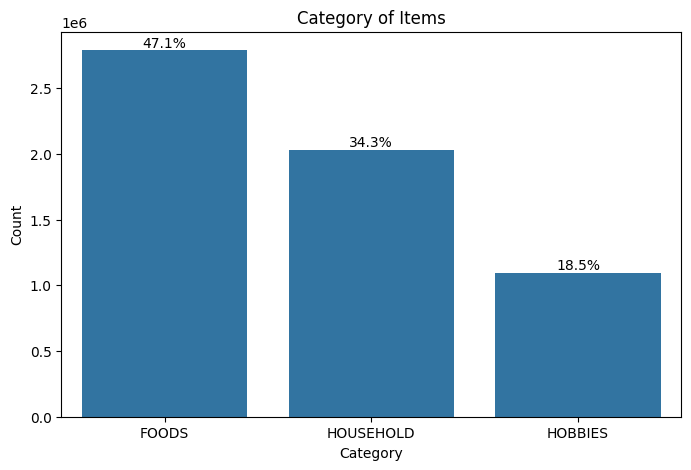

In [20]:
total = itemsCounts.sum()


plt.figure(figsize=(8,5))
ax = sns.barplot(x=categories, y=itemsCounts)
plt.title('Category of Items')
plt.xlabel('Category')
plt.ylabel('Count')

for patch, count in zip(ax.patches, itemsCounts):
    percent = count / total * 100
    ax.text(
        patch.get_x() + patch.get_width()/2,  # center of the bar
        patch.get_height(),                   # top of the bar
        f'{percent:.1f}%',                    # label text
        ha='center', va='bottom'
    )

plt.show()

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='cat_id', y='sell_price')
plt.title('Price Distribution by Category')
plt.xticks(rotation=45) # Rotates labels if you have many categories
plt.show()

KeyboardInterrupt: 

Household have highest and more expensive items. dot mean outliear  and normal becuase for items each will have thiar cost and class

lowest price is foods mid is hobbies and highest is household

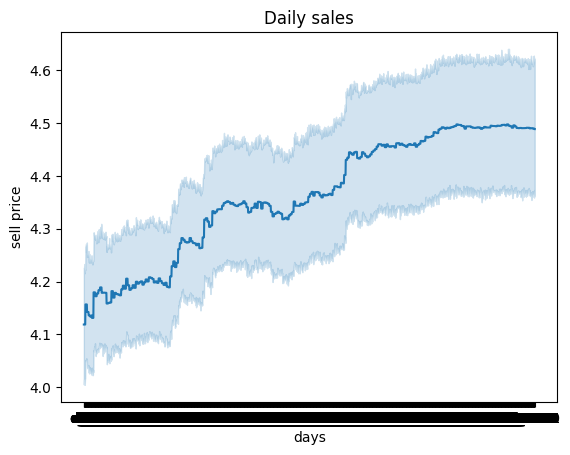

In [ ]:
sns.lineplot(data=df,x='d',y='sell_price')
plt.title('Daily sales')
plt.xlabel('days')
plt.ylabel('sell price')
plt.show()

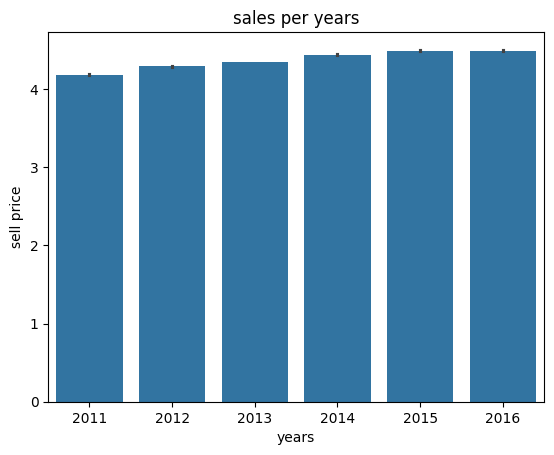

In [ ]:
sns.barplot(data=df,x='year',y='sell_price')
plt.title('sales per years')
plt.xlabel('years')
plt.ylabel('sell price')
plt.show()

In [ ]:
plt.figure(figsize=(12,6))  
sns.scatterplot(data=df, x='sell_price', y='revenue',hue='cat_id', s=10, alpha=0.5)
plt.title("Revenue vs Sell Price by Category")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.yscale('log')   
plt.show()

KeyboardInterrupt: 

In [ ]:
countPerDay=df['weekday'].value_counts()
days=countPerDay.index
countPerDay=countPerDay.values

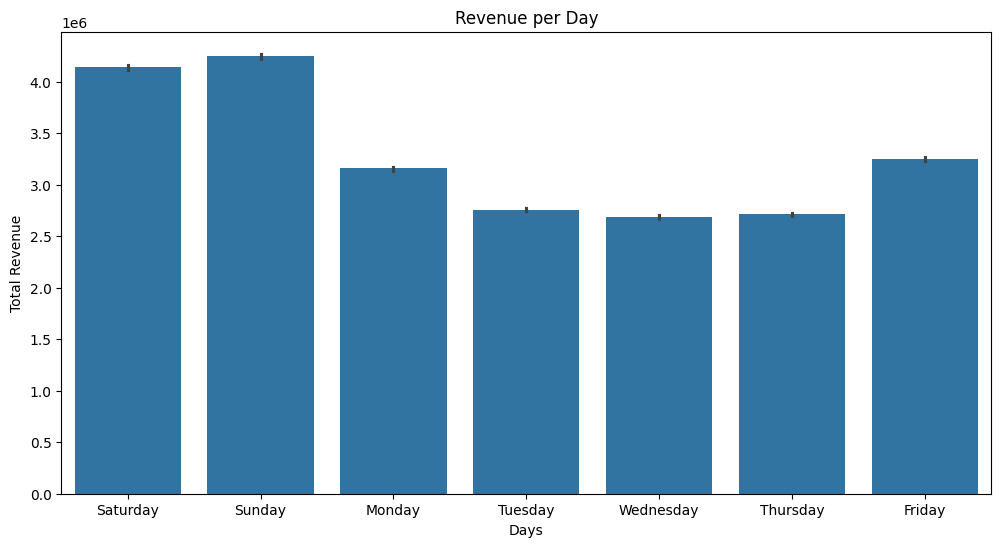

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='weekday',
    y='revenue',   
    estimator=sum  
)

plt.title('Revenue per Day')
plt.xlabel('Days')
plt.ylabel('Total Revenue')
plt.show()

In weekend we have more profit (revenue) compare with normal week days

In [22]:
df['date'] = pd.to_datetime(df['date'])

In [23]:
df['weekday'] = df['date'].dt.day_name()
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])


In [ ]:
df['weekday'].unique()

array(['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
       'Friday'], dtype=object)

In [25]:
df['event_name_1'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: event_name_1, dtype: object

In [ ]:
df['event_name_1'] = df['event_name_1'].fillna('Normal Day')
df['event_name_2'] = df['event_name_2'].fillna('Normal Day')

def combine_events(row):
    ev1 = row['event_name_1']
    ev2 = row['event_name_2']

    if ev1 != 'Normal Day' and ev2 != 'Normal Day':
        return f"{ev1} & {ev2}"

    elif ev1 != 'Normal Day':
        return ev1

    elif ev2 != 'Normal Day':
        return ev2

    else:
        return 'Normal Day'


df['combined_event'] = df.apply(combine_events, axis=1)


print(df[['event_name_1', 'event_name_2', 'combined_event']].head())

  event_name_1 event_name_2 combined_event
0   Normal Day   Normal Day     Normal Day
1   Normal Day   Normal Day     Normal Day
2   Normal Day   Normal Day     Normal Day
3   Normal Day   Normal Day     Normal Day
4   Normal Day   Normal Day     Normal Day


now work in Power BI

In [30]:
daily = df.groupby(['date', 'cat_id','weekday','is_weekend','sales','combined_event'])['revenue'].sum().reset_index()
daily.to_csv('daily_revenue.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5918109 entries, 0 to 5918108
Data columns (total 24 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            object        
 1   item_id       object        
 2   dept_id       object        
 3   cat_id        object        
 4   store_id      object        
 5   state_id      object        
 6   d             object        
 7   sales         int64         
 8   date          datetime64[ns]
 9   wm_yr_wk      int64         
 10  weekday       object        
 11  wday          int64         
 12  month         int64         
 13  year          int64         
 14  event_name_1  object        
 15  event_type_1  object        
 16  event_name_2  object        
 17  event_type_2  object        
 18  snap_CA       int64         
 19  snap_TX       int64         
 20  snap_WI       int64         
 21  sell_price    float64       
 22  revenue       float64       
 23  is_weekend    bool          
dty

Build model foracsting sell price

In [ ]:
# Check the range of your dates
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

# Count how many rows you have per year
print(df['date'].dt.year.value_counts().sort_index())

Start Date: 2011-01-29 00:00:00
End Date: 2016-05-22 00:00:00
date
2011    1027513
2012    1115934
2013    1112885
2014    1112885
2015    1112885
2016     436007
Name: count, dtype: int64


In [ ]:
df['weekday'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month